In [5]:
# Cell 1: Environment Setup and Library Imports
!pip install wfdb -q

import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import medfilt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")
print("WFDB Library Installed.")
print("Environment Ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
TensorFlow Version

In [9]:
# Cell 2: Batch Data Ingestion from PhysioNet using WFDB
def fetch_ctu_uhb_batch_wfdb(record_ids):
    """
    Downloads and parses real FHR and UC time-series data using the official PhysioNet WFDB package.
    """
    dataset = []
    print(f"Initiating WFDB download for {len(record_ids)} clinical records from PhysioNet...")

    for rec_id in record_ids:
        try:
            # The wfdb library handles the HTTP requests and decodes the binary .dat and .hea files automatically
            record = wfdb.rdrecord(rec_id, pn_dir='ctu-uhb-ctgdb/1.0.0/')

            # Extract the raw signal array (shape: samples x channels)
            signals = record.p_signal

            # Extract channel names to ensure correct mapping
            sig_names = record.sig_name
            fhr_idx = sig_names.index('FHR') if 'FHR' in sig_names else 0
            uc_idx = sig_names.index('UC') if 'UC' in sig_names else 1

            # Create a time array based on the clinical sampling rate (4 Hz)
            fs = record.fs
            time_sec = np.arange(signals.shape[0]) / fs

            df = pd.DataFrame({
                'Time_Sec': time_sec,
                'FHR': signals[:, fhr_idx],
                'UC': signals[:, uc_idx]
            })

            df['Patient_ID'] = str(rec_id)
            dataset.append(df)
            print(f"Successfully downloaded Record {rec_id} (Shape: {df.shape})")

        except Exception as e:
            print(f"Failed to fetch Record {rec_id}: {e}")

    return dataset

# Generate the list of the first 15 patient IDs as strings
patient_list = [str(i) for i in range(1001, 1016)]

raw_clinical_data = fetch_ctu_uhb_batch_wfdb(patient_list)
print(f"\nTotal patients successfully loaded: {len(raw_clinical_data)}")

Initiating WFDB download for 15 clinical records from PhysioNet...
Successfully downloaded Record 1001 (Shape: (19200, 4))
Successfully downloaded Record 1002 (Shape: (19200, 4))
Successfully downloaded Record 1003 (Shape: (18000, 4))
Successfully downloaded Record 1004 (Shape: (16800, 4))
Successfully downloaded Record 1005 (Shape: (18000, 4))
Successfully downloaded Record 1006 (Shape: (16800, 4))
Successfully downloaded Record 1007 (Shape: (15600, 4))
Successfully downloaded Record 1008 (Shape: (16800, 4))
Successfully downloaded Record 1009 (Shape: (20400, 4))
Successfully downloaded Record 1010 (Shape: (16800, 4))
Successfully downloaded Record 1011 (Shape: (15600, 4))
Successfully downloaded Record 1012 (Shape: (16800, 4))
Successfully downloaded Record 1013 (Shape: (18000, 4))
Successfully downloaded Record 1014 (Shape: (19200, 4))
Successfully downloaded Record 1015 (Shape: (19200, 4))

Total patients successfully loaded: 15


Running validation and digital filtering protocols...
Patient 1001 validated and cleaned.
Patient 1002 validated and cleaned.
Patient 1003 validated and cleaned.
Patient 1004 validated and cleaned.
Patient 1005 validated and cleaned.
Patient 1006 validated and cleaned.
Patient 1007 validated and cleaned.
Patient 1008 validated and cleaned.
Patient 1009 rejected: Signal loss too high (34.2%)
Patient 1010 validated and cleaned.
Patient 1011 validated and cleaned.
Patient 1012 rejected: Signal loss too high (33.7%)
Patient 1013 validated and cleaned.
Patient 1014 validated and cleaned.
Patient 1015 validated and cleaned.

Validation complete. Retained 13 high-quality patient records.


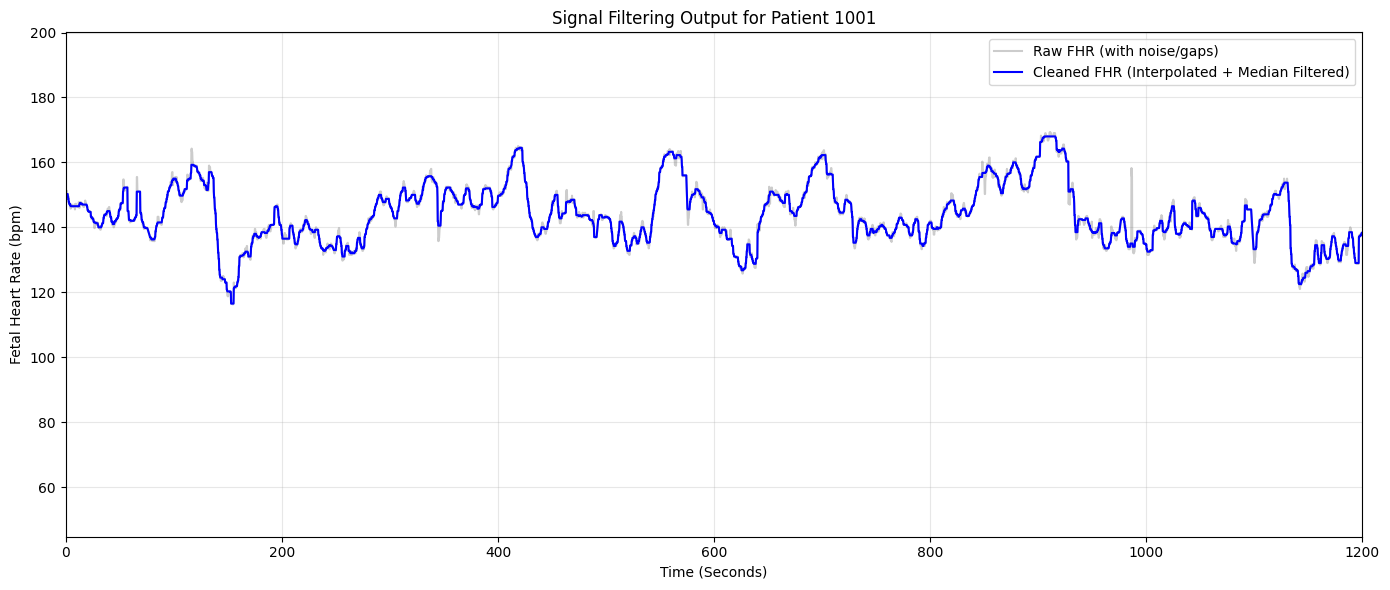

In [11]:
# Cell 3: Clinical Data Validation and Signal Cleaning
def clean_and_validate_signals(dataset, max_missing_threshold=0.3):
    """
    Cleans the raw data by handling sensor dropouts, applying median filters
    to remove artifact spikes, and validating physiological bounds.
    """
    clean_dataset = []

    print("Running validation and digital filtering protocols...")

    for df in dataset:
        df_clean = df.copy()
        patient_id = df_clean['Patient_ID'].iloc[0]

        # 1. Handle Missing Data
        # PhysioNet/WFDB represents signal loss as 0.0. We convert this to NaN for Pandas to handle.
        df_clean['FHR'] = df_clean['FHR'].replace(0.0, np.nan)
        df_clean['UC'] = df_clean['UC'].replace(0.0, np.nan)

        # Validation Check: If more than 30% of the FHR signal is missing, discard the patient entirely
        missing_ratio = df_clean['FHR'].isna().sum() / len(df_clean)
        if missing_ratio > max_missing_threshold:
            print(f"Patient {patient_id} rejected: Signal loss too high ({missing_ratio:.1%})")
            continue

        # 2. Interpolate missing segments
        # limit=40 means we only linearly interpolate gaps up to 10 seconds (4Hz * 10s = 40 samples)
        df_clean['FHR'] = df_clean['FHR'].interpolate(method='linear', limit=40)
        df_clean['UC'] = df_clean['UC'].interpolate(method='linear', limit=40)

        # Forward/Backward fill any remaining edge Nans so the filters don't crash
        df_clean.fillna(method='ffill', inplace=True)
        df_clean.fillna(method='bfill', inplace=True)

        # 3. Apply Median Filter to remove sudden artifact spikes (e.g., physical sensor bumps)
        # Kernel size of 15 (approx 3.75 seconds at 4Hz)
        df_clean['FHR_Filtered'] = medfilt(df_clean['FHR'].values, kernel_size=15)
        df_clean['UC_Filtered'] = medfilt(df_clean['UC'].values, kernel_size=15)

        clean_dataset.append(df_clean)
        print(f"Patient {patient_id} validated and cleaned.")

    print(f"\nValidation complete. Retained {len(clean_dataset)} high-quality patient records.")
    return clean_dataset

validated_data = clean_and_validate_signals(raw_clinical_data)

# Visualize the cleaning process for the first patient in the validated batch
if len(validated_data) > 0:
    sample = validated_data[0]
    plt.figure(figsize=(14, 6))

    # Plot raw FHR in the background
    plt.plot(sample['Time_Sec'], sample['FHR'], label='Raw FHR (with noise/gaps)', alpha=0.4, color='gray')

    # Plot the filtered, smoothed FHR in the foreground
    plt.plot(sample['Time_Sec'], sample['FHR_Filtered'], label='Cleaned FHR (Interpolated + Median Filtered)', color='blue', linewidth=1.5)

    plt.title(f"Signal Filtering Output for Patient {sample['Patient_ID'].iloc[0]}")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Fetal Heart Rate (bpm)")
    plt.legend()

    # Zoom into the first 20 minutes (1200 seconds) to clearly see the filter's effect
    plt.xlim(0, 1200)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
# Cell 4: Tensor Windowing, Feature Scaling, and Clinical Labeling
SAMPLING_RATE = 4 # Hz
WINDOW_MINUTES = 5
WINDOW_SIZE = WINDOW_MINUTES * 60 * SAMPLING_RATE # 1200 timesteps per window
STEP_SIZE = int(WINDOW_SIZE * 0.5) # 50% overlap for data augmentation

def generate_tensors_and_labels(dataset):
    X_list = []
    y_list = []

    scaler = StandardScaler()

    for df in dataset:
        # Scale the filtered signals
        scaled_signals = scaler.fit_transform(df[['FHR_Filtered', 'UC_Filtered']])

        # Use unscaled FHR to calculate clinical labels accurately
        raw_fhr = df['FHR_Filtered'].values

        # Sliding window extraction
        for start in range(0, len(scaled_signals) - WINDOW_SIZE, STEP_SIZE):
            end = start + WINDOW_SIZE

            # Extract Tensor Window
            window_features = scaled_signals[start:end, :]
            X_list.append(window_features)

            # Clinical Labeling Heuristic for this window
            # A window is flagged as "Distress" (1) if FHR drops below 110 bpm for more than 15 continuous seconds
            window_raw_fhr = raw_fhr[start:end]
            bradycardia_threshold = 110
            is_distressed = 0

            # Count consecutive samples below threshold
            consecutive_lows = 0
            max_consecutive_lows = 0
            for val in window_raw_fhr:
                if val < bradycardia_threshold:
                    consecutive_lows += 1
                    if consecutive_lows > max_consecutive_lows:
                        max_consecutive_lows = consecutive_lows
                else:
                    consecutive_lows = 0

            # 15 seconds * 4 Hz = 60 samples
            if max_consecutive_lows >= 60:
                is_distressed = 1

            y_list.append(is_distressed)

    return np.array(X_list), np.array(y_list)

print(f"Transforming continuous signals into {WINDOW_MINUTES}-minute overlapping tensors...")
X_data, y_labels = generate_tensors_and_labels(validated_data)

print(f"Final Input Tensor Shape: {X_data.shape} -> (Samples, Timesteps, Channels)")
print(f"Total Normal Windows: {np.sum(y_labels == 0)}")
print(f"Total Distressed Windows: {np.sum(y_labels == 1)}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

print(f"Training Set: {X_train.shape[0]} windows")
print(f"Testing Set: {X_test.shape[0]} windows")

Transforming continuous signals into 5-minute overlapping tensors...
Final Input Tensor Shape: (356, 1200, 2) -> (Samples, Timesteps, Channels)
Total Normal Windows: 193
Total Distressed Windows: 163
Training Set: 284 windows
Testing Set: 72 windows


In [13]:
# Cell 5: Extracting 2D Statistical Features for Baseline Models
print("Extracting statistical features for Random Forest Baseline...")

def extract_features_2d(X_tensor):
    X_flat = []
    for window in X_tensor:
        # window shape is (1200, 2) -> (FHR, UC)
        fhr = window[:, 0]
        uc = window[:, 1]

        # Calculate statistics for this 5-minute window
        features = [
            np.mean(fhr), np.std(fhr), np.min(fhr), np.max(fhr), # FHR Stats
            np.percentile(fhr, 25), np.percentile(fhr, 75),      # FHR Quartiles
            np.mean(uc), np.std(uc), np.max(uc),                 # UC Stats
            np.corrcoef(fhr, uc)[0, 1]                           # FHR/UC Correlation
        ]
        X_flat.append(features)
    return np.nan_to_num(np.array(X_flat)) # nan_to_num handles zero-variance edge cases

X_train_rf = extract_features_2d(X_train)
X_test_rf = extract_features_2d(X_test)

print(f"Random Forest Training Shape: {X_train_rf.shape}")

Extracting statistical features for Random Forest Baseline...
Random Forest Training Shape: (284, 10)


In [14]:
# Cell 6: Train and Evaluate Random Forest
from sklearn.ensemble import RandomForestClassifier

print("--- Training Model 1: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, class_weight='balanced')
rf_model.fit(X_train_rf, y_train)

# Predictions
rf_preds = rf_model.predict(X_test_rf)
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Random Forest ROC-AUC:  {rf_auc:.4f}")

--- Training Model 1: Random Forest ---
Random Forest Accuracy: 0.7917
Random Forest ROC-AUC:  0.9367


In [15]:
# Cell 7: Train and Evaluate 1D CNN
print("\n--- Training Model 2: 1D CNN ---")

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=15, activation='relu', input_shape=(WINDOW_SIZE, 2)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),

    Conv1D(filters=128, kernel_size=10, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

cnn_history = cnn_model.fit(X_train, y_train, epochs=30, batch_size=32,
                            validation_split=0.2, callbacks=callbacks, verbose=0)

cnn_probs = cnn_model.predict(X_test, verbose=0).flatten()
cnn_preds = (cnn_probs > 0.5).astype(int)

cnn_acc = accuracy_score(y_test, cnn_preds)
cnn_auc = roc_auc_score(y_test, cnn_probs)

print(f"1D CNN Accuracy: {cnn_acc:.4f}")
print(f"1D CNN ROC-AUC:  {cnn_auc:.4f}")


--- Training Model 2: 1D CNN ---
1D CNN Accuracy: 0.8056
1D CNN ROC-AUC:  0.8990


In [16]:
# Cell 8: Train and Evaluate Bidirectional LSTM
print("\n--- Training Model 3: Bidirectional LSTM ---")
# Warning: LSTMs on very long sequences (1200 steps) can be computationally heavy.

lstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW_SIZE, 2)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

lstm_history = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32,
                              validation_split=0.2, callbacks=callbacks, verbose=0)

lstm_probs = lstm_model.predict(X_test, verbose=0).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

lstm_acc = accuracy_score(y_test, lstm_preds)
lstm_auc = roc_auc_score(y_test, lstm_probs)

print(f"Bi-LSTM Accuracy: {lstm_acc:.4f}")
print(f"Bi-LSTM ROC-AUC:  {lstm_auc:.4f}")


--- Training Model 3: Bidirectional LSTM ---
Bi-LSTM Accuracy: 0.5556
Bi-LSTM ROC-AUC:  0.5431


In [17]:
# Cell 9: Train and Evaluate CNN-LSTM Hybrid
print("\n--- Training Model 4: CNN-LSTM Hybrid ---")

hybrid_model = Sequential([
    Conv1D(filters=64, kernel_size=20, strides=2, activation='relu', input_shape=(WINDOW_SIZE, 2)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),

    # Sequence is now much shorter and manageable for the LSTM
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32)),
    Dropout(0.4),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

hybrid_history = hybrid_model.fit(X_train, y_train, epochs=30, batch_size=32,
                                  validation_split=0.2, callbacks=callbacks, verbose=0)

hybrid_probs = hybrid_model.predict(X_test, verbose=0).flatten()
hybrid_preds = (hybrid_probs > 0.5).astype(int)

hybrid_acc = accuracy_score(y_test, hybrid_preds)
hybrid_auc = roc_auc_score(y_test, hybrid_probs)

print(f"Hybrid CNN-LSTM Accuracy: {hybrid_acc:.4f}")
print(f"Hybrid CNN-LSTM ROC-AUC:  {hybrid_auc:.4f}")


--- Training Model 4: CNN-LSTM Hybrid ---


Hybrid CNN-LSTM Accuracy: 0.6528
Hybrid CNN-LSTM ROC-AUC:  0.7125


In [18]:
# Cell 9.5: Experiment 5 - Classical Time-Series (ARIMA Feature Extraction)
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm # For progress tracking, as ARIMA fitting is slow

print("\n--- Training Model 5: ARIMA Coefficient Extractor ---")
print("Note: Fitting ARIMA models to thousands of individual time-series windows is computationally heavy.")

# Define the ARIMA order (p=AutoRegressive, d=Differencing, q=MovingAverage)
# We use a low order (2, 0, 2) to keep computation time reasonable for Colab
ARIMA_ORDER = (2, 0, 2)

def extract_arima_features(X_tensor):
    """
    Fits an ARIMA model to the FHR channel of each window and extracts
    the AR and MA coefficients to use as classification features.
    """
    arima_features = []

    # We use tqdm to show a progress bar because this loop takes time
    for i in tqdm(range(len(X_tensor)), desc="Fitting ARIMA to windows"):
        # Extract just the FHR signal from the 2-channel window
        fhr_signal = X_tensor[i, :, 0]

        try:
            # Fit the ARIMA model to this specific 5-minute window
            # enforce_stationarity and enforce_invertibility set to False to prevent crashing on chaotic biological data
            model = ARIMA(fhr_signal, order=ARIMA_ORDER, enforce_stationarity=False, enforce_invertibility=False)
            fitted_model = model.fit()

            # Extract the AR and MA coefficients (usually 4 parameters for order 2,0,2)
            # fitted_model.params contains [const, ar.L1, ar.L2, ma.L1, ma.L2, variance]
            coeffs = fitted_model.params
            arima_features.append(coeffs)

        except Exception as e:
            # If the optimizer fails to converge on a highly noisy window, return zeros as a fallback
            fallback_length = 1 + ARIMA_ORDER[0] + ARIMA_ORDER[2] + 1 # const + p + q + var
            arima_features.append(np.zeros(fallback_length))

    return np.array(arima_features)

print("Extracting ARIMA mathematical fingerprints for Training Data...")
X_train_arima = extract_arima_features(X_train)

print("Extracting ARIMA mathematical fingerprints for Testing Data...")
X_test_arima = extract_arima_features(X_test)

# Clean up any potential NaNs generated by non-converging ARIMA fits
X_train_arima = np.nan_to_num(X_train_arima)
X_test_arima = np.nan_to_num(X_test_arima)

# Train a Meta-Classifier on the extracted ARIMA coefficients
# Logistic Regression works well here to find linear relationships between the coefficients
print("\nTraining Meta-Classifier on ARIMA Features...")
arima_classifier = LogisticRegression(max_iter=1000, class_weight='balanced')
arima_classifier.fit(X_train_arima, y_train)

# Predictions
arima_preds = arima_classifier.predict(X_test_arima)
arima_probs = arima_classifier.predict_proba(X_test_arima)[:, 1]

arima_acc = accuracy_score(y_test, arima_preds)
arima_auc = roc_auc_score(y_test, arima_probs)

print(f"\nARIMA Extractor Accuracy: {arima_acc:.4f}")
print(f"ARIMA Extractor ROC-AUC:  {arima_auc:.4f}")


--- Training Model 5: ARIMA Coefficient Extractor ---
Note: Fitting ARIMA models to thousands of individual time-series windows is computationally heavy.
Extracting ARIMA mathematical fingerprints for Training Data...


Fitting ARIMA to windows:   0%|          | 0/284 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Extracting ARIMA mathematical fingerprints for Testing Data...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitting ARIMA to windows:   0%|          | 0/72 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Training Meta-Classifier on ARIMA Features...

ARIMA Extractor Accuracy: 0.7083
ARIMA Extractor ROC-AUC:  0.8050


In [19]:
# Cell 10: Experiment 6 - Time-Series Transformer (Self-Attention)
from tensorflow.keras import layers

print("\n--- Training Model 6: Time-Series Transformer ---")

# 1. Define the Transformer Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """
    Creates a single Transformer Encoder block using Multi-Head Attention.
    """
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

# 2. Build the Full Model
def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    # Optional: Initial 1D Convolution to create local feature embeddings before the Transformer
    # This helps the Transformer understand local shapes (like the curve of a single heartbeat) faster
    x = layers.Conv1D(filters=64, kernel_size=10, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Add multiple Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # Global pooling to flatten the sequence for the classifier head
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    # MLP Classifier Head
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs)

# Hyperparameters for the Transformer
input_shape = (WINDOW_SIZE, 2) # (1200, 2)
transformer_model = build_transformer_model(
    input_shape=input_shape,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=3,
    mlp_units=[64, 32],
    mlp_dropout=0.4,
    dropout=0.25,
)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly lower learning rate for Transformers
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name='auc')]
)

transformer_model.summary()

# 3. Train the Transformer
# Transformers are data-hungry and can take slightly longer to converge per epoch
transformer_history = transformer_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 4. Evaluate
transformer_probs = transformer_model.predict(X_test, verbose=0).flatten()
transformer_preds = (transformer_probs > 0.5).astype(int)

transformer_acc = accuracy_score(y_test, transformer_preds)
transformer_auc = roc_auc_score(y_test, transformer_probs)

print(f"\nTransformer Accuracy: {transformer_acc:.4f}")
print(f"Transformer ROC-AUC:  {transformer_auc:.4f}")


--- Training Model 6: Time-Series Transformer ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1200, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 600, 64)   │      1,344 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 600, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 600, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 600, 64)   │        128 │ re_lu[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 600, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 600, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 600, 64)   │          0 │ dropout_6[0][0],  │
│                     │                   │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 600, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 600, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 600, 128)  │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 600, 64)   │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 600, 64)   │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 600, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 600, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 600, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 600, 64)   │          0 │ dropout_9[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 600, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 600, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 291,777 (1.11 MB)

 Trainable params: 291,649 (1.11 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4537 - auc: 0.5170 - loss: 0.7260 - val_accuracy: 0.5965 - val_auc: 0.7188 - val_loss: 0.6800 - learning_rate: 5.0000e-04
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5947 - auc: 0.7095 - loss: 0.6279 - val_accuracy: 0.7193 - val_auc: 0.6904 - val_loss: 0.5823 - learning_rate: 5.0000e-04
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.7137 - auc: 0.8047 - loss: 0.5254 - val_accuracy: 0.7193 - val_auc: 0.8380 - val_loss: 0.6163 - learning_rate: 5.0000e-04
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8238 - auc: 0.9096 - loss: 0.3728 - val_accuracy: 0.7193 - val_auc: 0.8366 - val_loss: 0.5394 - learning_rate: 2.5000e-04
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8282 - auc: 0.8873 - loss: 0.4346 - val_accuracy: 0.7719 - val_auc: 0.8560 - val_loss: 0.5351 - learning_rate: 2.5000e-04
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.8106 - 

🏆 CHAMPION MODEL OF THE TOURNAMENT: Random Forest 🏆
Winning ROC-AUC: 0.9367 | Accuracy: 0.7917


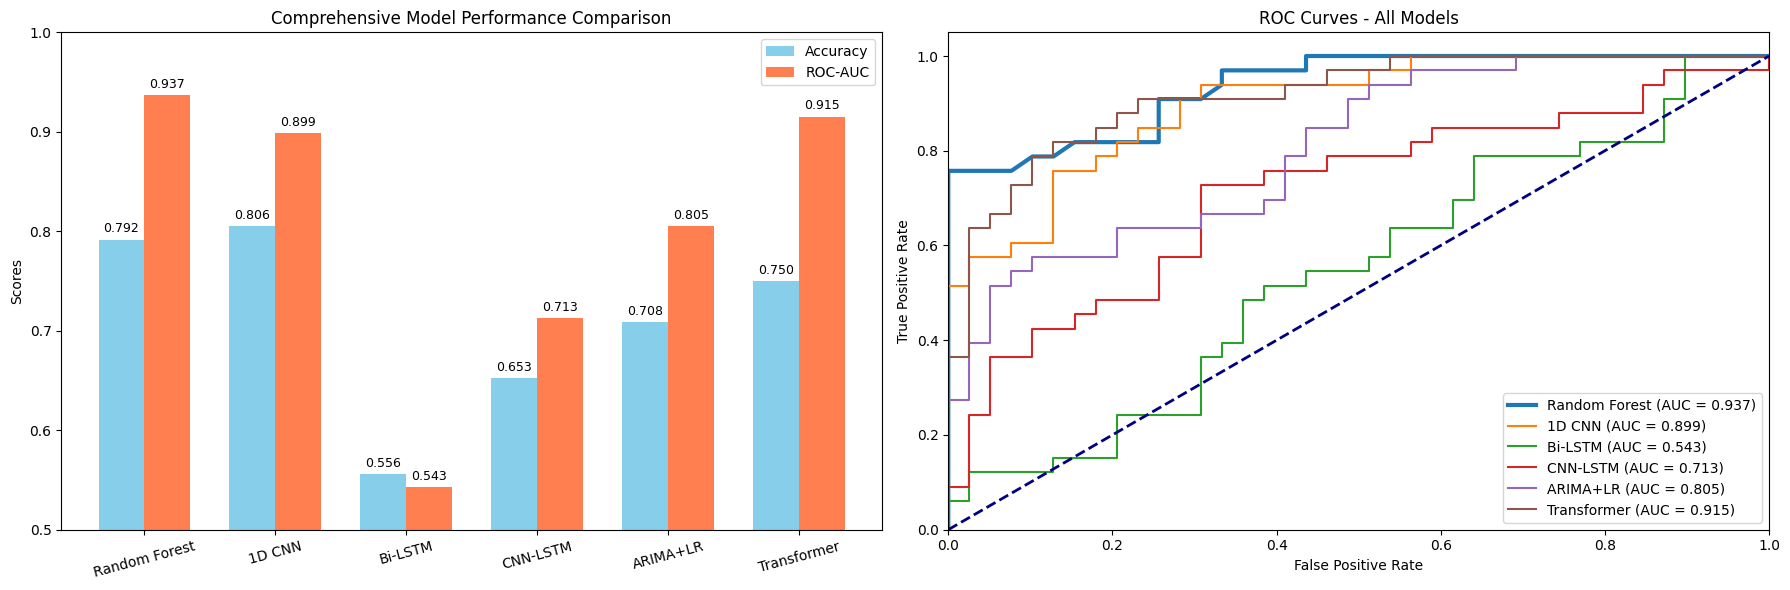

In [20]:
# Cell 11: Ultimate Master Evaluation and Champion Selection
models = ['Random Forest', '1D CNN', 'Bi-LSTM', 'CNN-LSTM', 'ARIMA+LR', 'Transformer']
accuracies = [rf_acc, cnn_acc, lstm_acc, hybrid_acc, arima_acc, transformer_acc]
auc_scores = [rf_auc, cnn_auc, lstm_auc, hybrid_auc, arima_auc, transformer_auc]
probabilities = [rf_probs, cnn_probs, lstm_probs, hybrid_probs, arima_probs, transformer_probs]

# Find the winner based on ROC-AUC
best_idx = np.argmax(auc_scores)
champion_name = models[best_idx]
champion_auc = auc_scores[best_idx]
champion_acc = accuracies[best_idx]

print("="*60)
print(f"🏆 CHAMPION MODEL OF THE TOURNAMENT: {champion_name} 🏆")
print(f"Winning ROC-AUC: {champion_auc:.4f} | Accuracy: {champion_acc:.4f}")
print("="*60)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Bar Chart Comparison
x = np.arange(len(models))
width = 0.35

rects1 = axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = axes[0].bar(x + width/2, auc_scores, width, label='ROC-AUC', color='coral')

axes[0].set_ylabel('Scores')
axes[0].set_title('Comprehensive Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

# Add value labels
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        axes[0].annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# 2. Combined ROC Curves
for i in range(len(models)):
    fpr, tpr, _ = roc_curve(y_test, probabilities[i])
    # Highlight the winner with a thicker line
    lw = 3 if i == best_idx else 1.5
    axes[1].plot(fpr, tpr, lw=lw, label=f'{models[i]} (AUC = {auc_scores[i]:.3f})')

axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - All Models')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Save the champion model
if champion_name == 'Transformer':
    transformer_model.save('champion_fetal_transformer.h5')
    print("The winning Transformer model has been saved.")